In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:


# If you don't have scikit-image:
# pip install scikit-image
from skimage.exposure import match_histograms

# -----------------------
# Settings
# -----------------------
input_folder = "/local/data1/jakli758/threeclasses/accepted"
output_folder = "/local/data1/jakli758/threeclasses/accepted_normalized"
os.makedirs(output_folder, exist_ok=True)

bins = 256

# Percentile clipping for robust rescale
LOW_PCT = 1
HIGH_PCT = 99

# CLAHE settings (tune these)
CLAHE_CLIPLIMIT = 2.0
CLAHE_TILEGRID = (8, 8)

# -----------------------
# Helpers
# -----------------------
def load_grayscale(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    # If multi-channel, convert to grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # If 16-bit, keep as uint16 for a moment; we'll normalize later
    return img

def robust_rescale_to_uint8(img: np.ndarray, low_pct=1, high_pct=99) -> np.ndarray:
    """Clip to percentiles and rescale to uint8 [0,255]. Works for uint8/uint16/float."""
    x = img.astype(np.float32)

    lo = np.percentile(x, low_pct)
    hi = np.percentile(x, high_pct)
    if hi <= lo:
        # fallback: just min/max
        lo, hi = float(x.min()), float(x.max())
        if hi <= lo:
            return np.zeros_like(img, dtype=np.uint8)

    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo)  # 0..1
    x = (255.0 * x).round().astype(np.uint8)
    return x

def apply_clahe(img_u8: np.ndarray, cliplimit=2.0, tilegrid=(8, 8)) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=cliplimit, tileGridSize=tilegrid)
    return clahe.apply(img_u8)

def hist_u8(img_u8: np.ndarray, bins=256) -> np.ndarray:
    h = cv2.calcHist([img_u8], [0], None, [bins], [0, 256]).flatten()
    s = h.sum()
    return h / s if s > 0 else h

# -----------------------
# Load all images
# -----------------------
paths = []
images_raw_u8 = []
names = []

print("loading images")
for fn in tqdm(sorted(os.listdir(input_folder))):
    p = os.path.join(input_folder, fn)
    img = load_grayscale(p)
    if img is None:
        continue
    img_u8 = robust_rescale_to_uint8(img, LOW_PCT, HIGH_PCT)
    paths.append(p)
    images_raw_u8.append(img_u8)
    names.append(fn)
print("loading images finished")
if len(images_raw_u8) == 0:
    raise RuntimeError("No readable images found in the input folder.")

# -----------------------
# Pick a reference image for histogram matching
# (Median mean intensity is usually a good stable choice)
# -----------------------
means = np.array([im.mean() for im in images_raw_u8])
ref_idx = int(np.argsort(means)[len(means)//2])
ref = images_raw_u8[ref_idx]

# -----------------------
# Process images: match histogram -> CLAHE
# -----------------------
images_processed = []
print("processing images")
for fn, img_u8 in tqdm(zip(names, images_raw_u8)):
    # Histogram match to reference (keeps distributions similar)
    matched = match_histograms(img_u8, ref, channel_axis=None).astype(np.uint8)

    # Local contrast enhancement
    enhanced = apply_clahe(matched, CLAHE_CLIPLIMIT, CLAHE_TILEGRID)

    images_processed.append(enhanced)

    # Save
    out_path = os.path.join(output_folder, fn)
    cv2.imwrite(out_path, enhanced)

print(f"Saved {len(images_processed)} processed images to: {output_folder}")
print(f"Reference image for matching: {names[ref_idx]} (mean intensity {means[ref_idx]:.1f})")

# -----------------------
# Plot histograms: before vs after
# -----------------------
combined_before = np.zeros(bins, dtype=np.float64)
combined_after = np.zeros(bins, dtype=np.float64)

hists_before = []
hists_after = []

print("creating histogram")
for fn, before, after in zip(names, images_raw_u8, images_processed):
    hb = hist_u8(before, bins)
    ha = hist_u8(after, bins)
    hists_before.append((fn, hb))
    hists_after.append((fn, ha))
    combined_before += hb
    combined_after += ha

combined_before /= combined_before.sum() if combined_before.sum() else 1.0
combined_after /= combined_after.sum() if combined_after.sum() else 1.0

# Combined plot
plt.figure()
plt.plot(combined_before, label="Before")
plt.plot(combined_after, label="After")
plt.title("Combined Intensity Distribution (All Images) - Before vs After")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Frequency")
plt.xlim([0, 255])
plt.legend()
plt.show()

# Per-image plot (can get crowded)
plt.figure()
for fn, hb in hists_before:
    plt.plot(hb, alpha=0.25)
plt.title("Per-Image Histograms - BEFORE")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Frequency")
plt.xlim([0, 255])
plt.show()

plt.figure()
for fn, ha in hists_after:
    plt.plot(ha, alpha=0.25)
plt.title("Per-Image Histograms - AFTER (Matched + CLAHE)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Frequency")
plt.xlim([0, 255])
plt.show()

loading images


  1%|          | 37/4335 [00:07<15:21,  4.66it/s]


KeyboardInterrupt: 

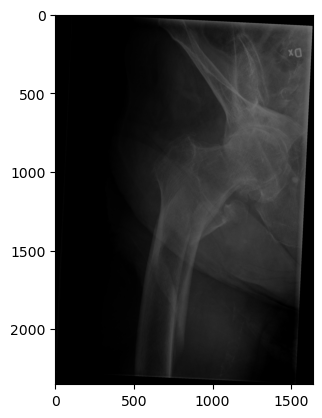

In [4]:
img = cv2.imread("/local/data1/jakli758/threeclasses/accepted/patient_10_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_4.png")
plt.imshow(img)

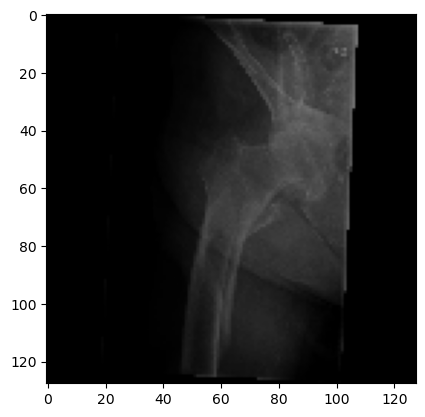

In [7]:
img = cv2.imread("/local/data1/jakli758/threeclasses/accepted_preprocessed_128/patient_10_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_4.png")
plt.imshow(img)

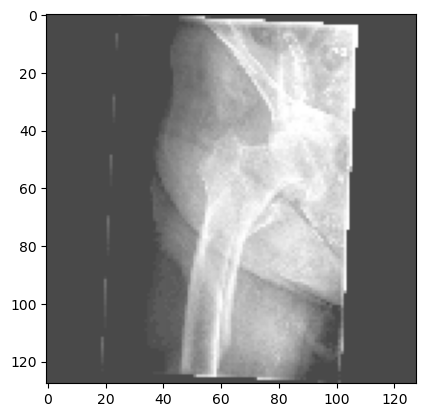

In [5]:
img = cv2.imread("/local/data1/jakli758/threeclasses/accepted_normalized_preprocessed_128/patient_10_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_4.png")
plt.imshow(img)

In [1]:
from utils import plot_img

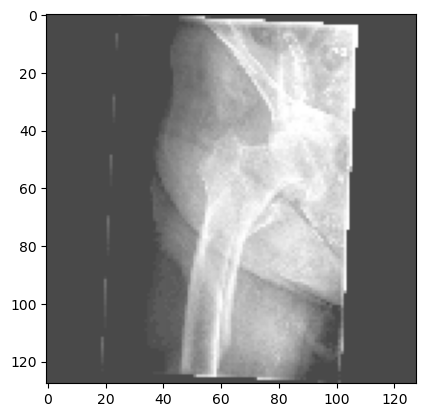

In [5]:
plot_img("/local/data1/jakli758/threeclasses/accepted_normalized_preprocessed_128/patient_10_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_4.png")

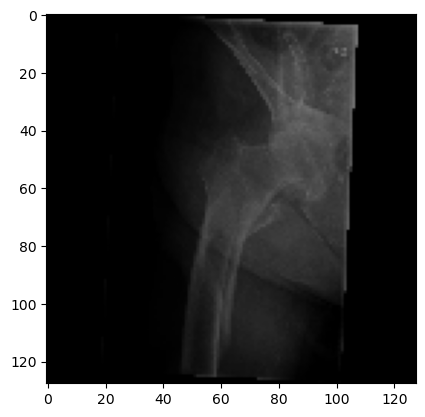

In [6]:
plot_img("/local/data1/jakli758/threeclasses/accepted_preprocessed_128/patient_10_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_4.png")

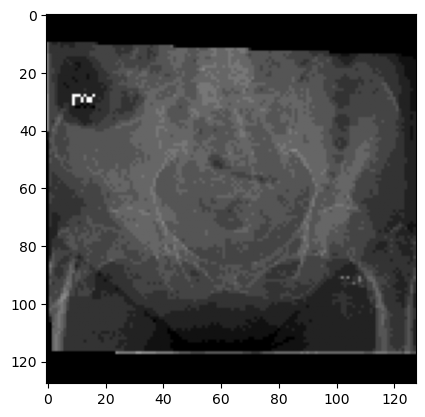

In [11]:
plot_img("/local/data1/jakli758/threeclasses/accepted_preprocessed_128/patient_75_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_1.png", is_rgb=False)

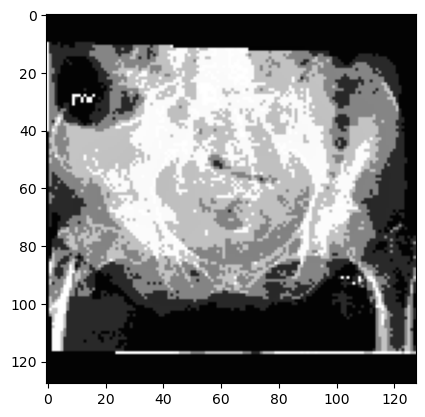

In [9]:
plot_img("/local/data1/jakli758/threeclasses/accepted_normalized_preprocessed_128/patient_75_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_1.png")

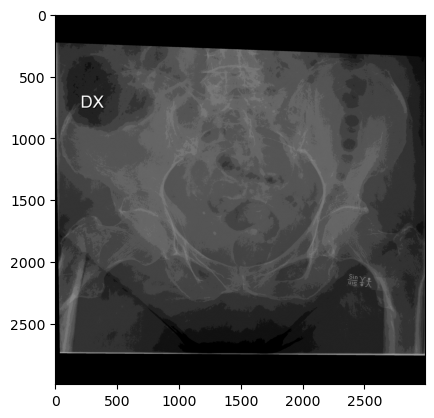

In [13]:
plot_img("/local/data1/jakli758/threeclasses/accepted/patient_75_CONTROL_class_1_modality_CR_scanoccasion_0_imagenumber_1.png", is_rgb=False)

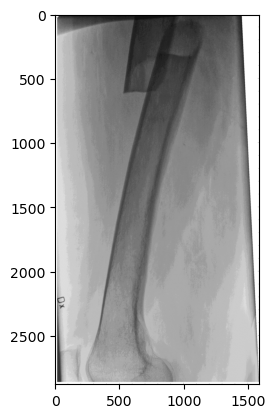

In [10]:
plot_img("/local/data1/jakli758/threeclasses/accepted/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_3.png",0)

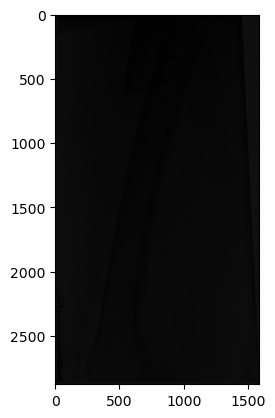

In [16]:
path = "/local/data1/jakli758/threeclasses/accepted/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_3.png"
img = cv2.imread(path)
#cv2.imwrite("/local/data1/jakli758/thesis_code/tmp.png", img)
plt.imshow(img)

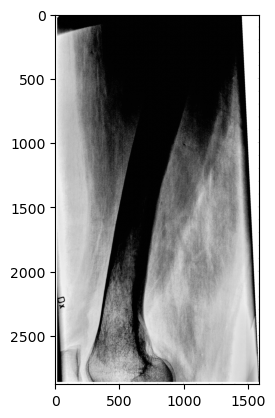

In [8]:
plot_img("/local/data1/jakli758/threeclasses/accepted_normalized/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_3.png",0)

In [2]:
import utils

In [3]:
utils.datasplit_dm_raw()

Loading images


100%|██████████| 1414/1414 [00:00<00:00, 571142.71it/s]


100%|██████████| 4335/4335 [00:00<00:00, 512596.43it/s]


Performing datasplit
Copying files to target directory


100%|██████████| 120/120 [00:02<00:00, 46.05it/s]


Patient distribution:
Train: Counter({'CONTROL': 739, 'AFF': 200, 'HEALTHY': 25})
Val: Counter({'CONTROL': 83, 'AFF': 22, 'HEALTHY': 3})
Test:  Counter({'CONTROL': 92, 'AFF': 25, 'HEALTHY': 3})

File distribution per split:

TRAIN:
  AFF     : 700
  CONTROL : 2822
  HEALTHY : 1111
  TOTAL   : 4633

VAL:
  AFF     : 74
  CONTROL : 301
  HEALTHY : 161
  TOTAL   : 536

TEST:
  AFF     : 94
  CONTROL : 344
  HEALTHY : 142
  TOTAL   : 580

GRAND TOTAL: 5749


Dataset successfully created at: /local/data1/jakli758/dataset_normalized/dm/raw/


  0%|          | 0/700 [00:00<?, ?it/s]

100%|██████████| 700/700 [02:00<00:00,  5.82it/s]


Saved 700 normalized images to /local/data1/jakli758/dataset_normalized/gan/normalized/train_AFF


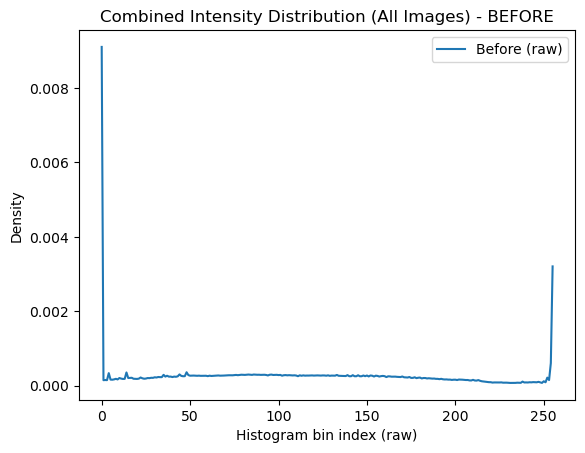

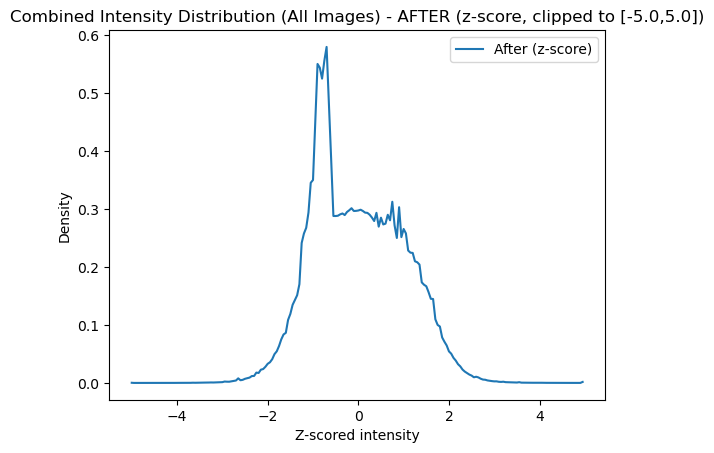

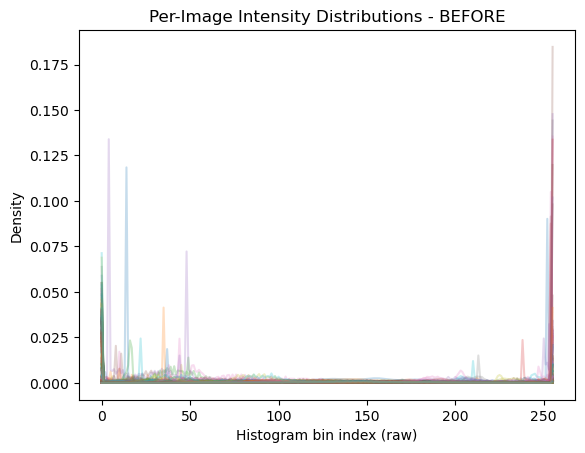

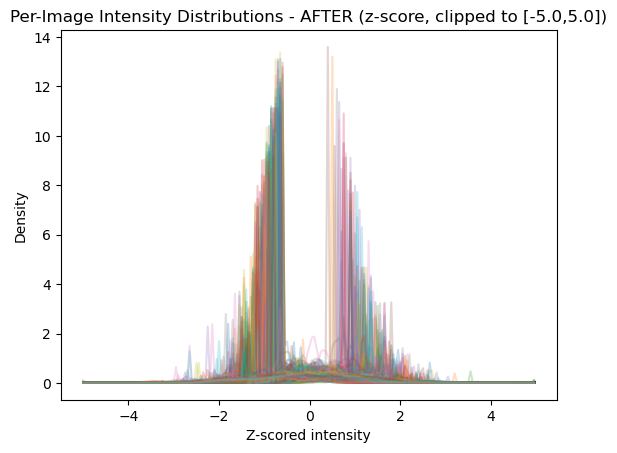

Z-score means:  mean=0.0000, min=-0.0000, max=0.0000
Z-score stds :  mean=1.0000, min=1.0000, max=1.0000


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


# -----------------------
# Settings
# -----------------------
input_folder = "/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF"
output_folder = "/local/data1/jakli758/dataset_normalized/gan/normalized/train_AFF"
os.makedirs(output_folder, exist_ok=True)

save_visualization_png = True

# Histogram settings
bins_before = 256              # for raw uint8-like intensities
bins_after = 200               # for z-scored values
z_clip = 5.0                   # clip z values to [-z_clip, z_clip] for histogram stability

# If you have many images, per-image plot can get crowded
alpha_per_image = 0.25


# -----------------------
# Helpers
# -----------------------
def load_grayscale(path: str) -> np.ndarray | None:
    """Load an image as grayscale. Supports common formats; returns None if unreadable."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def to_float(img: np.ndarray) -> np.ndarray:
    return img.astype(np.float32)

def zscore_normalize(img: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Per-image z-score normalization: (img - mean) / std."""
    x = to_float(img)
    mu = float(x.mean())
    sigma = float(x.std())
    if sigma < eps:
        # avoid divide-by-zero; return zeros if image is constant
        return np.zeros_like(x, dtype=np.float32)
    return (x - mu) / sigma

def hist_raw(img: np.ndarray, bins: int = 256) -> np.ndarray:
    """Histogram for raw intensities. If uint16/float, uses min/max range."""
    x = img.astype(np.float32).ravel()
    lo, hi = float(x.min()), float(x.max())
    if hi <= lo:
        h = np.zeros(bins, dtype=np.float64)
        h[0] = 1.0
        return h
    h, _ = np.histogram(x, bins=bins, range=(lo, hi), density=True)
    return h

def hist_z(img_z: np.ndarray, bins: int = 200, z_clip: float = 5.0) -> np.ndarray:
    """Histogram for z-scored image, clipped to [-z_clip, z_clip]."""
    x = np.clip(img_z, -z_clip, z_clip).ravel()
    h, _ = np.histogram(x, bins=bins, range=(-z_clip, z_clip), density=True)
    return h


# -----------------------
# Load + compute
# -----------------------
names = []
raw_images = []
z_images = []

for fn in tqdm(sorted(os.listdir(input_folder))):
    in_path = os.path.join(input_folder, fn)
    img = load_grayscale(in_path)
    if img is None:
        continue

    z_img = zscore_normalize(img)

    names.append(fn)
    raw_images.append(img)
    z_images.append(z_img)

    # Save true normalized image (float32)
    base_name = os.path.splitext(fn)[0]
    #np.save(os.path.join(output_folder, base_name + ".npy"), z_img)

    # Optional: Save visualization PNG (rescaled to 0-255 for viewing only)
    if save_visualization_png:
        vis = np.clip(z_img, -z_clip, z_clip)
        vis = (vis + z_clip) / (2 * z_clip)  # scale to 0–1
        vis = (255 * vis).astype(np.uint8)
        cv2.imwrite(os.path.join(output_folder, base_name + ".png"), vis)

print(f"Saved {len(z_images)} normalized images to {output_folder}")

# Precompute histograms
raw_hists = [hist_raw(im, bins_before) for im in raw_images]
z_hists = [hist_z(imz, bins_after, z_clip) for imz in z_images]

# Combined histograms (average of per-image densities)
combined_raw = np.mean(np.stack(raw_hists, axis=0), axis=0)
combined_z = np.mean(np.stack(z_hists, axis=0), axis=0)

# X-axes for plotting
# Raw: we don't know each image's exact min/max mapping after histogramming,
# so for a meaningful x-axis you may prefer converting all to uint8 first.
# Here we just plot the curve index for the combined raw histogram.
x_raw = np.arange(bins_before)

x_z = np.linspace(-z_clip, z_clip, bins_after, endpoint=False)


# -----------------------
# Plots: Combined (before vs after)
# -----------------------
plt.figure()
plt.plot(x_raw, combined_raw, label="Before (raw)")
plt.title("Combined Intensity Distribution (All Images) - BEFORE")
plt.xlabel("Histogram bin index (raw)")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure()
plt.plot(x_z, combined_z, label="After (z-score)")
plt.title(f"Combined Intensity Distribution (All Images) - AFTER (z-score, clipped to [-{z_clip},{z_clip}])")
plt.xlabel("Z-scored intensity")
plt.ylabel("Density")
plt.legend()
plt.show()


# -----------------------
# Plots: Per-image curves (before and after)
# -----------------------
plt.figure()
for fn, h in zip(names, raw_hists):
    plt.plot(x_raw, h, alpha=alpha_per_image)
plt.title("Per-Image Intensity Distributions - BEFORE")
plt.xlabel("Histogram bin index (raw)")
plt.ylabel("Density")
plt.show()

plt.figure()
for fn, h in zip(names, z_hists):
    plt.plot(x_z, h, alpha=alpha_per_image)
plt.title(f"Per-Image Intensity Distributions - AFTER (z-score, clipped to [-{z_clip},{z_clip}])")
plt.xlabel("Z-scored intensity")
plt.ylabel("Density")
plt.show()


# -----------------------
# Sanity check: mean ~0, std ~1 per image
# -----------------------
means = np.array([imz.mean() for imz in z_images])
stds = np.array([imz.std() for imz in z_images])

print(f"Z-score means:  mean={means.mean():.4f}, min={means.min():.4f}, max={means.max():.4f}")
print(f"Z-score stds :  mean={stds.mean():.4f}, min={stds.min():.4f}, max={stds.max():.4f}")

In [7]:
from utils import plot_img

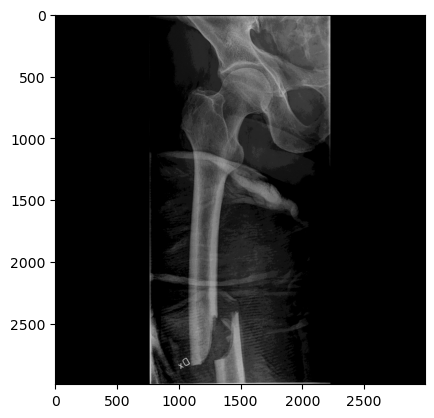

In [13]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png", False)

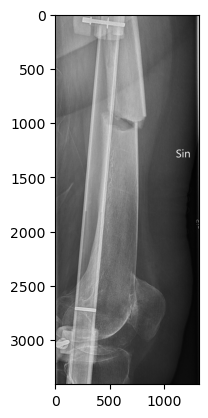

In [14]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized/train_AFF/patient_1184_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_4.png", False)

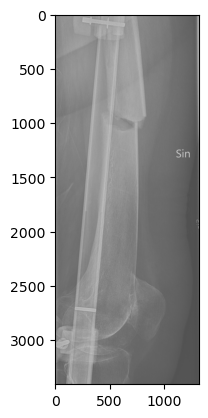

In [15]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized/train_AFF/patient_1184_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_4.png", True)

100%|██████████| 700/700 [03:34<00:00,  3.26it/s]


Saved 700 normalized images to: /local/data1/jakli758/dataset_normalized/gan/normalized_median/train_AFF


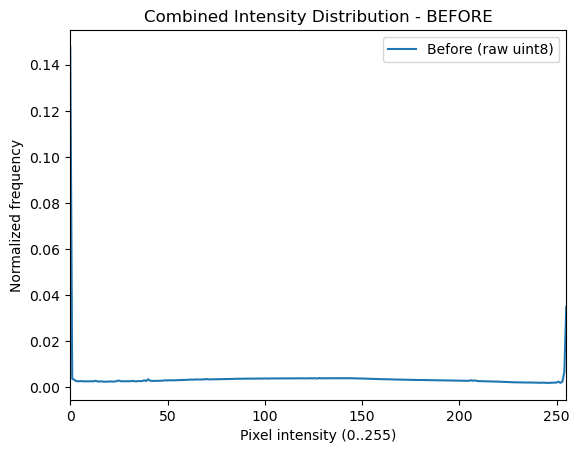

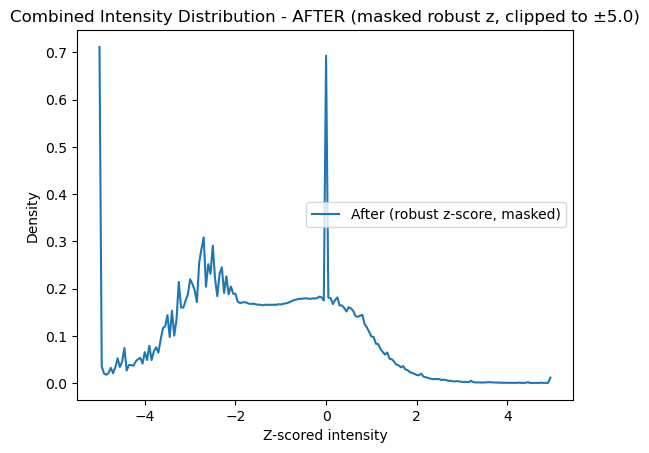

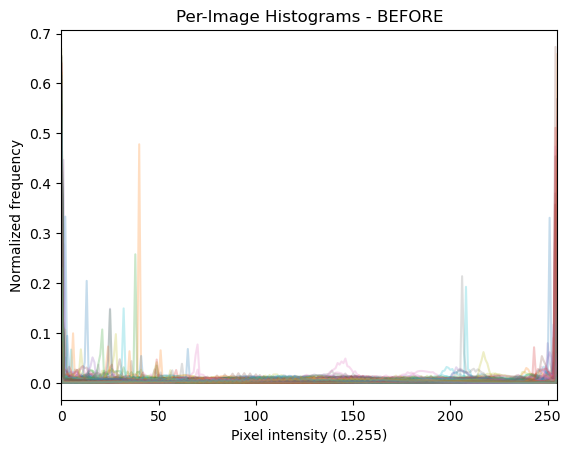

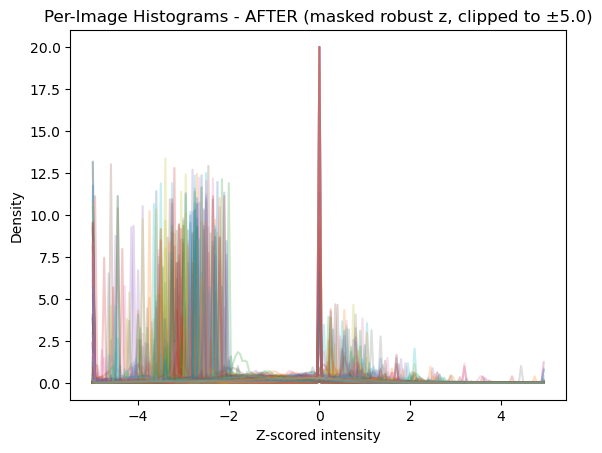

Masked z median: mean=0.0000, min=0.0000, max=0.0000
Masked z std   : mean=1.0650, min=0.0000, max=78.0484


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


# -----------------------
# Settings
# -----------------------
input_folder = "/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF"
output_folder = "/local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_AFF"
os.makedirs(output_folder, exist_ok=True)

# Histogram settings
bins_before = 256
bins_after = 200
z_clip = 5.0
alpha_per_image = 0.25

save_visualization_png = True  # saves *_vis.png for quick viewing

# Foreground mask settings
# If your background is black-ish, Otsu works well.
USE_OTSU = True
FIXED_THRESH = 10  # used only if USE_OTSU=False (0..255), tweak if needed
MORPH_KERNEL = 7   # size for morphological cleanup; try 5,7,9
MIN_FG_FRAC = 0.01 # if mask is too tiny, fall back to whole image


# -----------------------
# Helpers
# -----------------------
def load_grayscale(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def to_uint8(img: np.ndarray, low_pct=1, high_pct=99) -> np.ndarray:
    """Clip to percentiles and rescale to uint8 [0,255]. Works for uint8/uint16/float."""
    x = img.astype(np.float32)

    lo = np.percentile(x, low_pct)
    hi = np.percentile(x, high_pct)
    if hi <= lo:
        # fallback: just min/max
        lo, hi = float(x.min()), float(x.max())
        if hi <= lo:
            return np.zeros_like(img, dtype=np.uint8)

    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo)  # 0..1
    x = (255.0 * x).round().astype(np.uint8)
    return x

def make_foreground_mask(img_u8):
    """
    Returns a boolean mask of the foreground (leg/bone region).
    Assumes background is darker than foreground (typical X-ray exports).
    """
    if USE_OTSU:
        # Otsu threshold; foreground = above threshold
        _, th = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, th = cv2.threshold(img_u8, FIXED_THRESH, 255, cv2.THRESH_BINARY)

    # Morphological cleanup: close holes, remove speckles
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, k)

    mask = th.astype(bool)

    # If mask is tiny or empty, fall back to whole image
    if mask.mean() < MIN_FG_FRAC:
        mask = np.ones_like(mask, dtype=bool)

    return mask

def robust_zscore_with_mask(img, mask, eps=1e-8):
    """
    Robust z-score using median + IQR computed only on masked pixels.
    z = (x - median) / (IQR/1.349)
    """
    x = img.astype(np.float32)
    vals = x[mask]

    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)

    med = float(np.median(vals))
    q1 = float(np.percentile(vals, 25))
    q3 = float(np.percentile(vals, 75))
    iqr = q3 - q1

    # Convert IQR to a "robust std" estimate (Gaussian assumption)
    robust_sigma = iqr / 1.349 if iqr > eps else 0.0
    if robust_sigma < eps:
        return np.zeros_like(x, dtype=np.float32)

    z = (x - med) / robust_sigma
    return z

def hist_raw(img_u8, bins=256):
    h = cv2.calcHist([img_u8], [0], None, [bins], [0, 256]).flatten()
    s = h.sum()
    return h / s if s > 0 else h

def hist_z(img_z, bins=200, z_clip=5.0):
    x = np.clip(img_z, -z_clip, z_clip).ravel()
    h, _ = np.histogram(x, bins=bins, range=(-z_clip, z_clip), density=True)
    return h


# -----------------------
# Process folder
# -----------------------
names = []
raw_u8_images = []
z_images = []

for fn in tqdm(sorted(os.listdir(input_folder))):
    in_path = os.path.join(input_folder, fn)
    img = load_grayscale(in_path)
    if img is None:
        continue

    img_u8 = to_uint8(img)
    mask = make_foreground_mask(img_u8)

    z_img = robust_zscore_with_mask(img, mask)

    names.append(fn)
    raw_u8_images.append(img_u8)
    z_images.append(z_img)

    base = os.path.splitext(fn)[0]

    # Save normalized float image (best for training)
    #np.save(os.path.join(output_folder, base + ".npy"), z_img.astype(np.float32))

    # Optional visualization PNG (NOT for training; it rescales to 0..255)
    if save_visualization_png:
        vis = np.clip(z_img, -z_clip, z_clip)
        vis = (vis + z_clip) / (2 * z_clip)  # -> 0..1
        vis = (255 * vis).round().astype(np.uint8)
        cv2.imwrite(os.path.join(output_folder, base + "_vis.png"), vis)

print(f"Saved {len(z_images)} normalized images to: {output_folder}")


# -----------------------
# Histograms before/after
# -----------------------
raw_hists = [hist_raw(im, bins_before) for im in raw_u8_images]
z_hists = [hist_z(imz, bins_after, z_clip) for imz in z_images]

combined_raw = np.mean(np.stack(raw_hists, axis=0), axis=0)
combined_z = np.mean(np.stack(z_hists, axis=0), axis=0)

x_raw = np.arange(bins_before)
x_z = np.linspace(-z_clip, z_clip, bins_after, endpoint=False)

# Combined
plt.figure()
plt.plot(x_raw, combined_raw, label="Before (raw uint8)")
plt.title("Combined Intensity Distribution - BEFORE")
plt.xlabel("Pixel intensity (0..255)")
plt.ylabel("Normalized frequency")
plt.xlim([0, 255])
plt.legend()
plt.show()

plt.figure()
plt.plot(x_z, combined_z, label="After (robust z-score, masked)")
plt.title(f"Combined Intensity Distribution - AFTER (masked robust z, clipped to ±{z_clip})")
plt.xlabel("Z-scored intensity")
plt.ylabel("Density")
plt.legend()
plt.show()

# Per-image curves
plt.figure()
for h in raw_hists:
    plt.plot(x_raw, h, alpha=alpha_per_image)
plt.title("Per-Image Histograms - BEFORE")
plt.xlabel("Pixel intensity (0..255)")
plt.ylabel("Normalized frequency")
plt.xlim([0, 255])
plt.show()

plt.figure()
for h in z_hists:
    plt.plot(x_z, h, alpha=alpha_per_image)
plt.title(f"Per-Image Histograms - AFTER (masked robust z, clipped to ±{z_clip})")
plt.xlabel("Z-scored intensity")
plt.ylabel("Density")
plt.show()


# -----------------------
# Sanity checks
# -----------------------
# Check that (within the mask) median ~0 and robust sigma ~1-ish is expected.
# Global mean/std of the whole image will not necessarily be 0/1 due to background.
meds = []
sigmas = []
for img_u8, img, z in zip(raw_u8_images, [load_grayscale(os.path.join(input_folder, n)) for n in names], z_images):
    m = make_foreground_mask(img_u8)
    vals = z[m]
    if vals.size:
        meds.append(float(np.median(vals)))
        sigmas.append(float(vals.std()))
print(f"Masked z median: mean={np.mean(meds):.4f}, min={np.min(meds):.4f}, max={np.max(meds):.4f}")
print(f"Masked z std   : mean={np.mean(sigmas):.4f}, min={np.min(sigmas):.4f}, max={np.max(sigmas):.4f}")

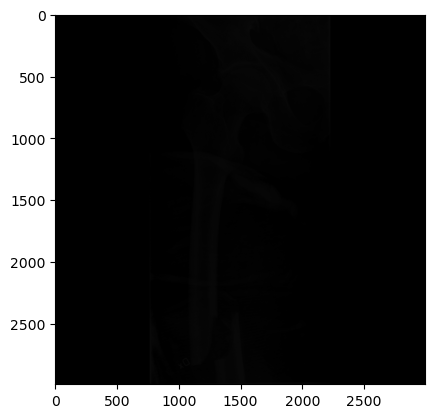

In [17]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

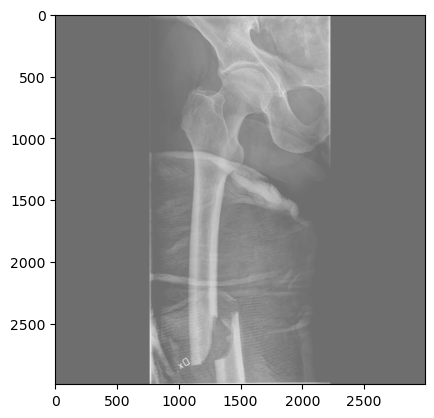

In [18]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

[ WARN:0@1658.502] global loadsave.cpp:275 findDecoder imread_('/local/data1/jakli758/dataset_normalized/gan/normalized_median/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png'): can't open/read file: check file path/integrity


TypeError: Image data of dtype object cannot be converted to float

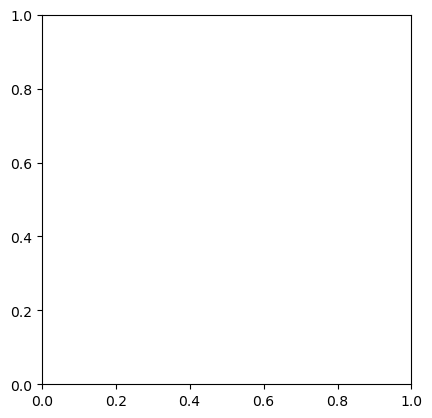

In [20]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized_median/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

100%|██████████| 700/700 [03:25<00:00,  3.40it/s]


Saved 700 normalized images to /local/data1/jakli758/dataset_normalized/gan/normalized_median/train_AFF


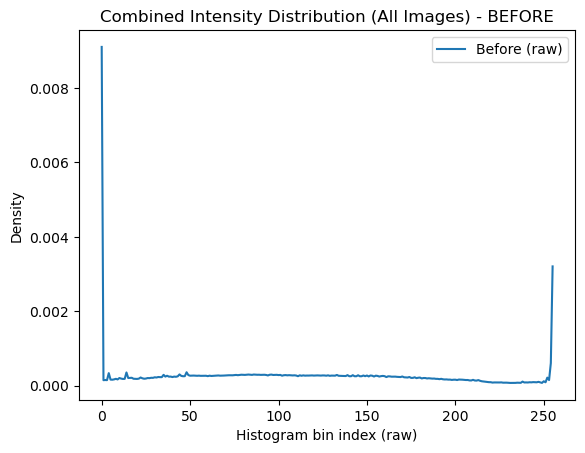

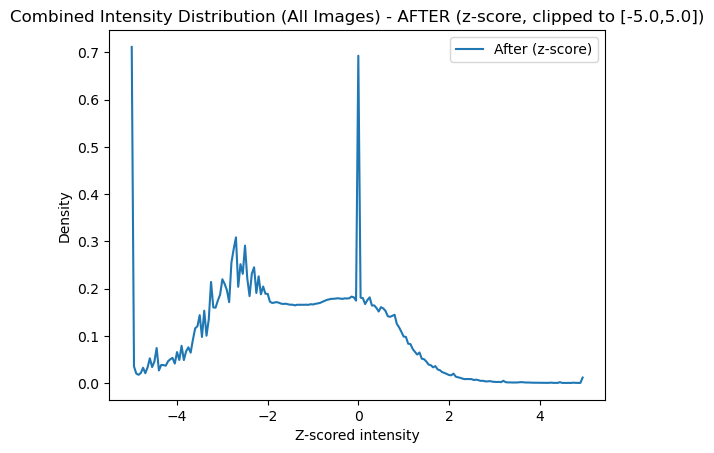

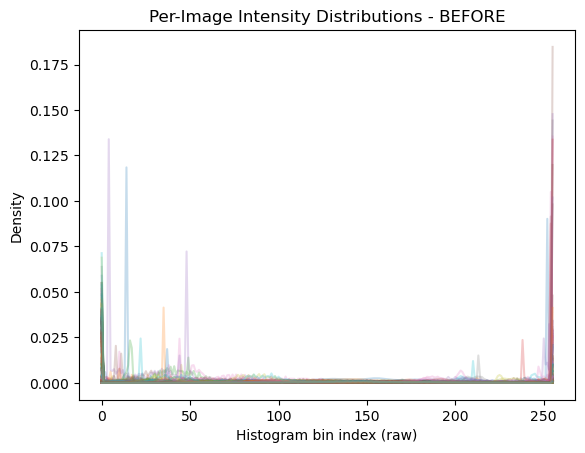

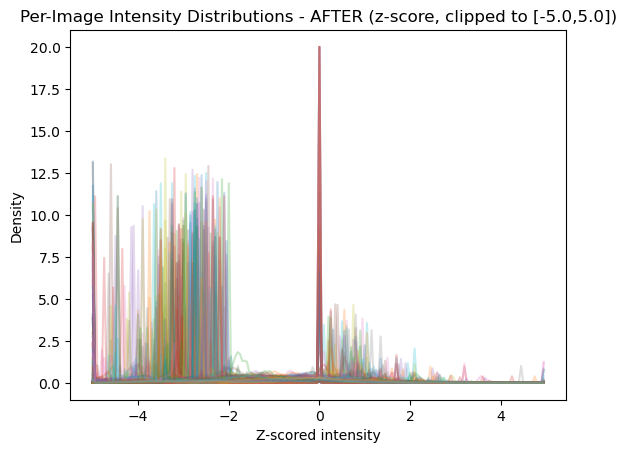

Z-score means:  mean=-1.9619, min=-232.5958, max=0.0000
Z-score stds :  mean=2.2035, min=0.0000, max=281.4143


In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


# -----------------------
# Settings
# -----------------------
input_folder = "/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF"
output_folder = "/local/data1/jakli758/dataset_normalized/gan/normalized_median/train_AFF"
os.makedirs(output_folder, exist_ok=True)

save_visualization_png = True

# Histogram settings
bins_before = 256              # for raw uint8-like intensities
bins_after = 200               # for z-scored values
z_clip = 5.0                   # clip z values to [-z_clip, z_clip] for histogram stability

# If you have many images, per-image plot can get crowded
alpha_per_image = 0.25


# -----------------------
# Helpers
# -----------------------
def load_grayscale(path: str) -> np.ndarray | None:
    """Load an image as grayscale. Supports common formats; returns None if unreadable."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def to_float(img: np.ndarray) -> np.ndarray:
    return img.astype(np.float32)

def zscore_normalize(img: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Per-image z-score normalization: (img - mean) / std."""
    x = to_float(img)
    mu = float(x.mean())
    sigma = float(x.std())
    if sigma < eps:
        # avoid divide-by-zero; return zeros if image is constant
        return np.zeros_like(x, dtype=np.float32)
    return (x - mu) / sigma

def hist_raw(img: np.ndarray, bins: int = 256) -> np.ndarray:
    """Histogram for raw intensities. If uint16/float, uses min/max range."""
    x = img.astype(np.float32).ravel()
    lo, hi = float(x.min()), float(x.max())
    if hi <= lo:
        h = np.zeros(bins, dtype=np.float64)
        h[0] = 1.0
        return h
    h, _ = np.histogram(x, bins=bins, range=(lo, hi), density=True)
    return h

def hist_z(img_z: np.ndarray, bins: int = 200, z_clip: float = 5.0) -> np.ndarray:
    """Histogram for z-scored image, clipped to [-z_clip, z_clip]."""
    x = np.clip(img_z, -z_clip, z_clip).ravel()
    h, _ = np.histogram(x, bins=bins, range=(-z_clip, z_clip), density=True)
    return h


def make_foreground_mask(img_u8):
    """
    Returns a boolean mask of the foreground (leg/bone region).
    Assumes background is darker than foreground (typical X-ray exports).
    """
    if USE_OTSU:
        # Otsu threshold; foreground = above threshold
        _, th = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, th = cv2.threshold(img_u8, FIXED_THRESH, 255, cv2.THRESH_BINARY)

    # Morphological cleanup: close holes, remove speckles
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, k)

    mask = th.astype(bool)

    # If mask is tiny or empty, fall back to whole image
    if mask.mean() < MIN_FG_FRAC:
        mask = np.ones_like(mask, dtype=bool)

    return mask

def robust_zscore_with_mask(img, mask, eps=1e-8):
    """
    Robust z-score using median + IQR computed only on masked pixels.
    z = (x - median) / (IQR/1.349)
    """
    x = img.astype(np.float32)
    vals = x[mask]

    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)

    med = float(np.median(vals))
    q1 = float(np.percentile(vals, 25))
    q3 = float(np.percentile(vals, 75))
    iqr = q3 - q1

    # Convert IQR to a "robust std" estimate (Gaussian assumption)
    robust_sigma = iqr / 1.349 if iqr > eps else 0.0
    if robust_sigma < eps:
        return np.zeros_like(x, dtype=np.float32)

    z = (x - med) / robust_sigma
    return z

# -----------------------
# Load + compute
# -----------------------
names = []
raw_images = []
z_images = []

for fn in tqdm(sorted(os.listdir(input_folder))):
    in_path = os.path.join(input_folder, fn)
    img = load_grayscale(in_path)
    if img is None:
        continue

    img_u8 = to_uint8(img)
    mask = make_foreground_mask(img_u8)

    z_img = robust_zscore_with_mask(img, mask)

    names.append(fn)
    raw_images.append(img)
    z_images.append(z_img)

    # Save true normalized image (float32)
    base_name = os.path.splitext(fn)[0]
    #np.save(os.path.join(output_folder, base_name + ".npy"), z_img)

    # Optional: Save visualization PNG (rescaled to 0-255 for viewing only)
    if save_visualization_png:
        vis = np.clip(z_img, -z_clip, z_clip)
        vis = (vis + z_clip) / (2 * z_clip)  # scale to 0–1
        vis = (255 * vis).astype(np.uint8)
        cv2.imwrite(os.path.join(output_folder, base_name + ".png"), vis)

print(f"Saved {len(z_images)} normalized images to {output_folder}")

# Precompute histograms
raw_hists = [hist_raw(im, bins_before) for im in raw_images]
z_hists = [hist_z(imz, bins_after, z_clip) for imz in z_images]

# Combined histograms (average of per-image densities)
combined_raw = np.mean(np.stack(raw_hists, axis=0), axis=0)
combined_z = np.mean(np.stack(z_hists, axis=0), axis=0)

# X-axes for plotting
# Raw: we don't know each image's exact min/max mapping after histogramming,
# so for a meaningful x-axis you may prefer converting all to uint8 first.
# Here we just plot the curve index for the combined raw histogram.
x_raw = np.arange(bins_before)

x_z = np.linspace(-z_clip, z_clip, bins_after, endpoint=False)


# -----------------------
# Plots: Combined (before vs after)
# -----------------------
plt.figure()
plt.plot(x_raw, combined_raw, label="Before (raw)")
plt.title("Combined Intensity Distribution (All Images) - BEFORE")
plt.xlabel("Histogram bin index (raw)")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure()
plt.plot(x_z, combined_z, label="After (z-score)")
plt.title(f"Combined Intensity Distribution (All Images) - AFTER (z-score, clipped to [-{z_clip},{z_clip}])")
plt.xlabel("Z-scored intensity")
plt.ylabel("Density")
plt.legend()
plt.show()


# -----------------------
# Plots: Per-image curves (before and after)
# -----------------------
plt.figure()
for fn, h in zip(names, raw_hists):
    plt.plot(x_raw, h, alpha=alpha_per_image)
plt.title("Per-Image Intensity Distributions - BEFORE")
plt.xlabel("Histogram bin index (raw)")
plt.ylabel("Density")
plt.show()

plt.figure()
for fn, h in zip(names, z_hists):
    plt.plot(x_z, h, alpha=alpha_per_image)
plt.title(f"Per-Image Intensity Distributions - AFTER (z-score, clipped to [-{z_clip},{z_clip}])")
plt.xlabel("Z-scored intensity")
plt.ylabel("Density")
plt.show()


# -----------------------
# Sanity check: mean ~0, std ~1 per image
# -----------------------
means = np.array([imz.mean() for imz in z_images])
stds = np.array([imz.std() for imz in z_images])

print(f"Z-score means:  mean={means.mean():.4f}, min={means.min():.4f}, max={means.max():.4f}")
print(f"Z-score stds :  mean={stds.mean():.4f}, min={stds.min():.4f}, max={stds.max():.4f}")

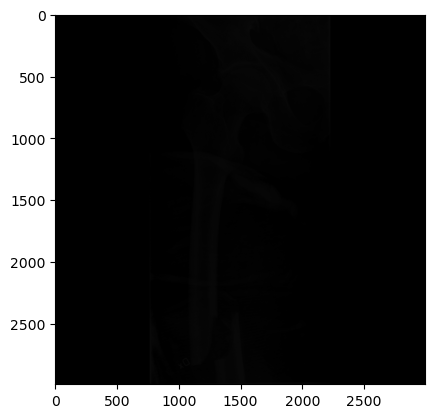

In [22]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

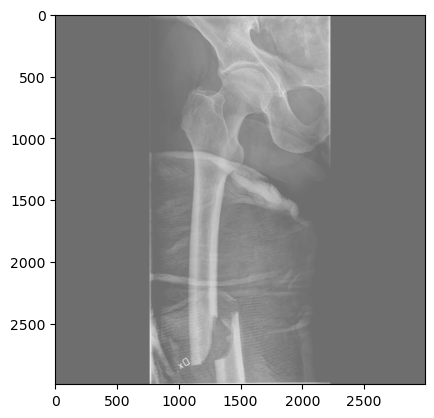

In [23]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

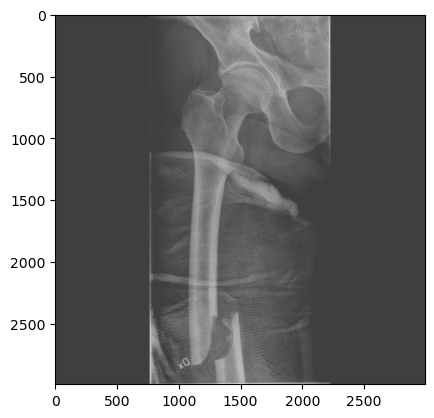

In [25]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized_mask_mean/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

  0%|          | 0/700 [00:00<?, ?it/s]

100%|██████████| 700/700 [03:25<00:00,  3.40it/s]


Saved 700 visualization images to: /local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_AFF


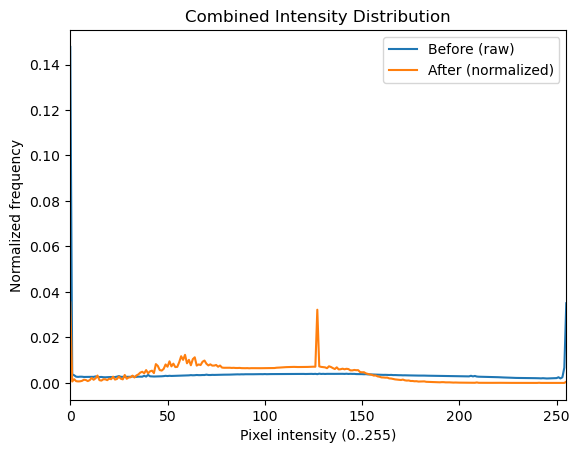

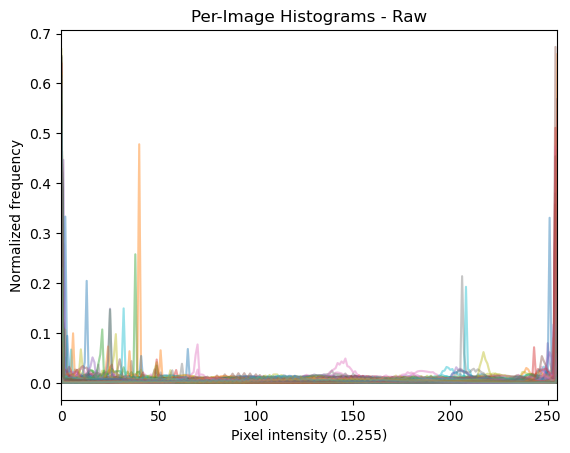

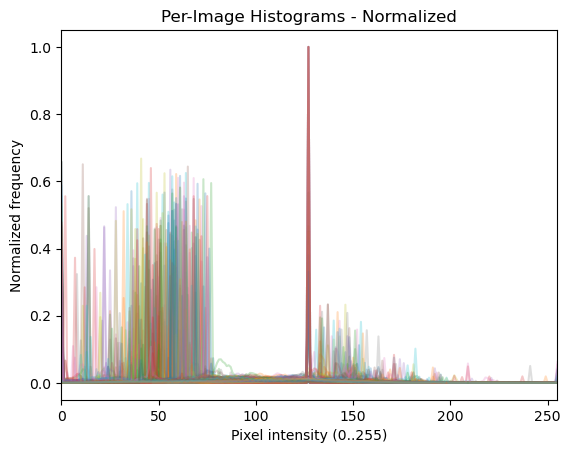

In [29]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# -----------------------
# Settings
# -----------------------
input_folder = "/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF"
output_folder = "/local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_AFF"
os.makedirs(output_folder, exist_ok=True)

save_visualization_png = True

# Histogram settings
bins_before = 256              
bins_after = 256              
z_clip = 5.0                   # clip z values to [-z_clip, z_clip] for histogram stability

# If you have many images, per-image plot can get crowded
alpha_per_image = 0.25


# -----------------------
# Helpers
# -----------------------
def load_grayscale(path: str) -> np.ndarray | None:
    """Load an image as grayscale. Supports common formats; returns None if unreadable."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def to_float(img: np.ndarray) -> np.ndarray:
    return img.astype(np.float32)

def zscore_normalize(img: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Per-image z-score normalization: (img - mean) / std."""
    x = to_float(img)
    mu = float(x.mean())
    sigma = float(x.std())
    if sigma < eps:
        # avoid divide-by-zero; return zeros if image is constant
        return np.zeros_like(x, dtype=np.float32)
    return (x - mu) / sigma

def hist_raw(img: np.ndarray, bins: int = 256) -> np.ndarray:
    """Histogram for raw intensities. If uint16/float, uses min/max range."""
    x = img.astype(np.float32).ravel()
    lo, hi = float(x.min()), float(x.max())
    if hi <= lo:
        h = np.zeros(bins, dtype=np.float64)
        h[0] = 1.0
        return h
    h, _ = np.histogram(x, bins=bins, range=(lo, hi), density=True)
    return h

def hist_z(img_z: np.ndarray, bins: int = 200, z_clip: float = 5.0) -> np.ndarray:
    """Histogram for z-scored image, clipped to [-z_clip, z_clip]."""
    x = np.clip(img_z, -z_clip, z_clip).ravel()
    h, _ = np.histogram(x, bins=bins, range=(-z_clip, z_clip), density=True)
    return h


def make_foreground_mask(img_u8):
    """
    Returns a boolean mask of the foreground (leg/bone region).
    Assumes background is darker than foreground (typical X-ray exports).
    """
    if USE_OTSU:
        # Otsu threshold; foreground = above threshold
        _, th = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, th = cv2.threshold(img_u8, FIXED_THRESH, 255, cv2.THRESH_BINARY)

    # Morphological cleanup: close holes, remove speckles
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, k)

    mask = th.astype(bool)

    # If mask is tiny or empty, fall back to whole image
    if mask.mean() < MIN_FG_FRAC:
        mask = np.ones_like(mask, dtype=bool)

    return mask

def robust_zscore_with_mask(img, mask, eps=1e-8):
    """
    Robust z-score using median + IQR computed only on masked pixels.
    z = (x - median) / (IQR/1.349)
    """
    x = img.astype(np.float32)
    vals = x[mask]

    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)

    med = float(np.median(vals))
    q1 = float(np.percentile(vals, 25))
    q3 = float(np.percentile(vals, 75))
    iqr = q3 - q1

    # Convert IQR to a "robust std" estimate (Gaussian assumption)
    robust_sigma = iqr / 1.349 if iqr > eps else 0.0
    if robust_sigma < eps:
        return np.zeros_like(x, dtype=np.float32)

    z = (x - med) / robust_sigma
    return z

# -----------------------
# Load + compute
# -----------------------
names = []
raw_images = []
z_images = []
vis_u8_images = []

for fn in tqdm(sorted(os.listdir(input_folder))):
    in_path = os.path.join(input_folder, fn)
    img = load_grayscale(in_path)
    if img is None:
        continue

    img_u8 = to_uint8(img)
    mask = make_foreground_mask(img_u8)

    z_img = robust_zscore_with_mask(img, mask)

    names.append(fn)
    raw_images.append(img)

    # Save true normalized image (float32)
    base_name = os.path.splitext(fn)[0]
    #np.save(os.path.join(output_folder, base_name + ".npy"), z_img)

    # Optional: Save visualization PNG (rescaled to 0-255 for viewing only)

    vis = np.clip(z_img, -z_clip, z_clip)
    vis = (vis + z_clip) / (2 * z_clip)  # scale to 0–1
    vis = (255 * vis).astype(np.uint8)
    cv2.imwrite(os.path.join(output_folder, base_name + ".png"), vis)

    names.append(fn)
    raw_u8_images.append(img_u8)
    vis_u8_images.append(vis)

print(f"Saved {len(vis_u8_images)} visualization images to: {output_folder}")

if len(vis_u8_images) == 0:
    raise RuntimeError("No images processed. Check input_folder and file formats.")


# -----------------------
# Histograms before/after
# -----------------------
raw_hists = [hist_u8(im, bins_before) for im in raw_u8_images]
vis_hists = [hist_u8(im, bins_after) for im in vis_u8_images]

combined_raw = np.mean(np.stack(raw_hists, axis=0), axis=0) if raw_hists else np.zeros(bins_before)
combined_vis = np.mean(np.stack(vis_hists, axis=0), axis=0) if vis_hists else np.zeros(bins_after)

x_u8 = np.arange(256)

# Combined (before vs after)
plt.figure()
plt.plot(x_u8, combined_raw, label="Before (raw)")
plt.plot(x_u8, combined_vis, label="After (normalized)")
plt.title("Combined Intensity Distribution")
plt.xlabel("Pixel intensity (0..255)")
plt.ylabel("Normalized frequency")
plt.xlim([0, 255])
plt.legend()
plt.show()

# Per-image curves (before)
plt.figure()
for h in raw_hists:
    plt.plot(x_u8, h, alpha=alpha_per_image)
plt.title("Per-Image Histograms - Raw")
plt.xlabel("Pixel intensity (0..255)")
plt.ylabel("Normalized frequency")
plt.xlim([0, 255])
plt.show()

# Per-image curves (after)
plt.figure()
for h in vis_hists:
    plt.plot(x_u8, h, alpha=alpha_per_image)
plt.title("Per-Image Histograms - Normalized")
plt.xlabel("Pixel intensity (0..255)")
plt.ylabel("Normalized frequency")
plt.xlim([0, 255])
plt.show()

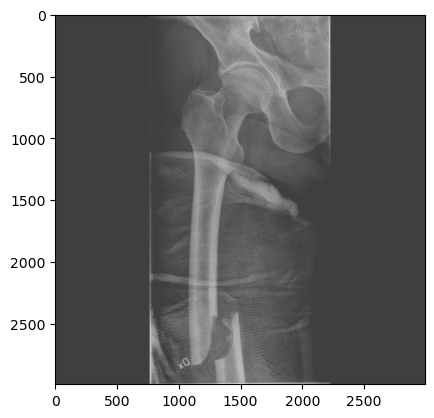

In [31]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized_mask_mean/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

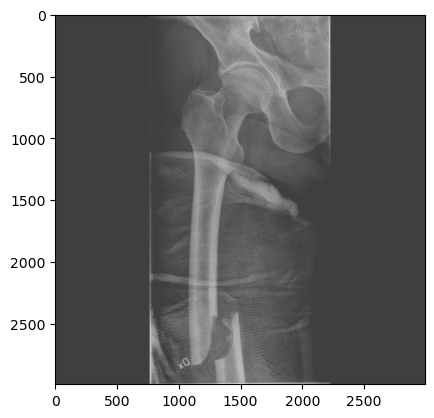

In [30]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_AFF/patient_525_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_2.png")

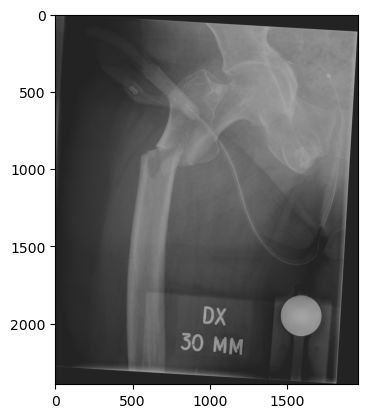

In [32]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_AFF/patient_1185_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_1.png")

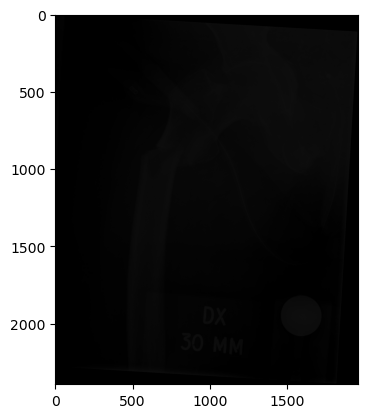

In [33]:
plot_img("/local/data1/jakli758/dataset_normalized/gan/raw/train_AFF/patient_1185_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_1.png")

In [34]:
from utils import normalize_and_plot_hist

100%|██████████| 2822/2822 [25:10<00:00,  1.87it/s]  


Saved 2822 normalized images to: /local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_NFF


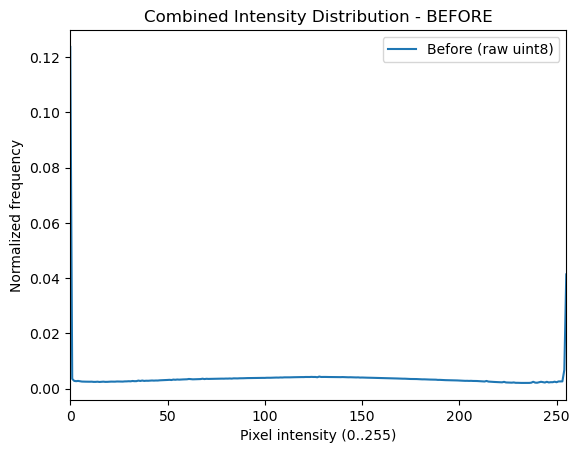

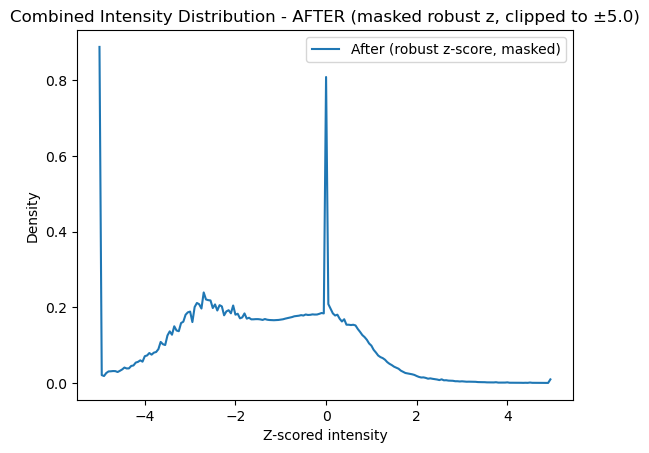

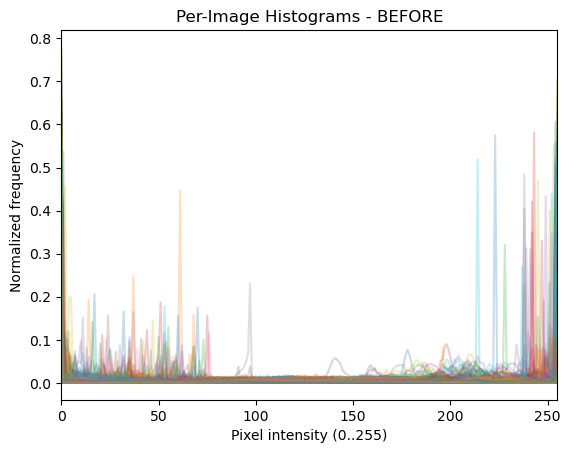

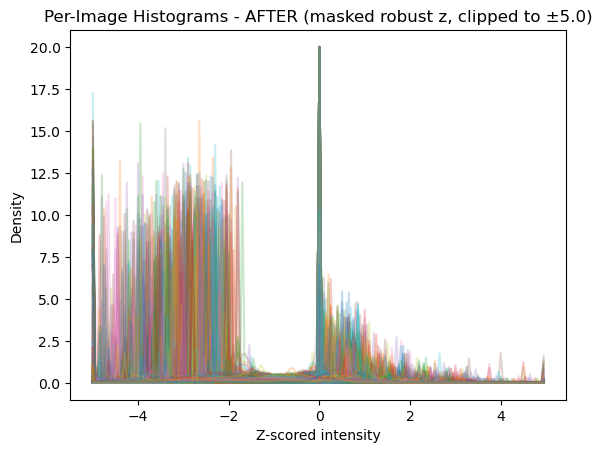

In [ ]:
normalize_and_plot_hist("/local/data1/jakli758/dataset_normalized/gan/raw/train_NFF", "/local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_NFF")

In [ ]:
normalize_and_plot_hist("/local/data1/jakli758/dataset_normalized/gan/raw/train_HEALTHY", "/local/data1/jakli758/dataset_normalized/gan/normalized_mask_median/train_HEALTHY")

  0%|          | 0/1111 [00:00<?, ?it/s]

100%|██████████| 1111/1111 [16:21<00:00,  1.13it/s] 

Saved 1111 normalized images to: /local/data1/jakli758/dataset_normalized/gan/normalized_masked_median/train_HEALTHY


### New approach for normalization acording to Anders' mail

In [8]:
from utils import normalize_domain_level
from utils import plot_img

In [11]:
path = "/local/data1/jakli758/dataset_normalized/gan/"
normalize_domain_level(f"{path}raw_gray_128/train_AFF", f"{path}normalized_gray_128/train_AFF")

  0%|          | 0/2800 [00:00<?, ?it/s]

100%|██████████| 2800/2800 [00:00<00:00, 3328.23it/s]


Global mean: 71.68476104736328
Global std: 80.70891571044922


100%|██████████| 2800/2800 [00:04<00:00, 691.70it/s]

Normalization finished.


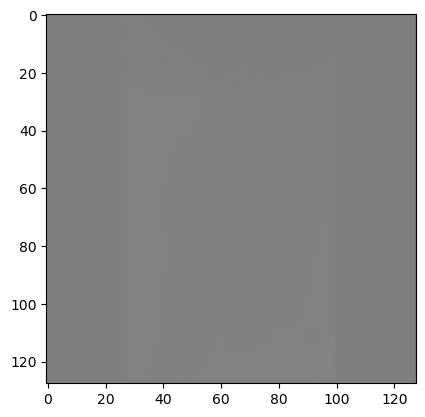

In [12]:
plot_img(f"{path}normalized_gray_128/train_AFF/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_5.png")

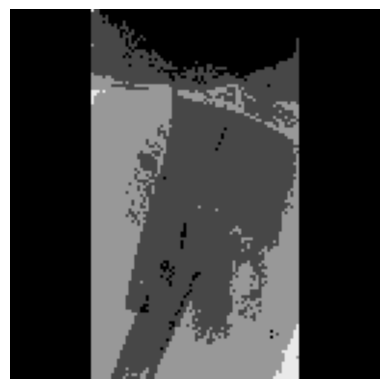

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# example values (replace with the ones printed during normalization)
global_mean = np.array([71.68476104736328, 71.68476104736328, 71.68476104736328])
global_std = np.array([80.70891571044922, 80.70891571044922, 80.70891571044922])

# read normalized image
img = cv2.imread(f"{path}normalized_gray_128/train_AFF/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_5.png", cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

# revert normalization
restored = (img - 128) * global_std + global_mean

# clip to valid uint8 range
restored = np.clip(restored, 0, 255).astype(np.uint8)

# visualize
plt.imshow(restored)
plt.axis("off")
plt.show()

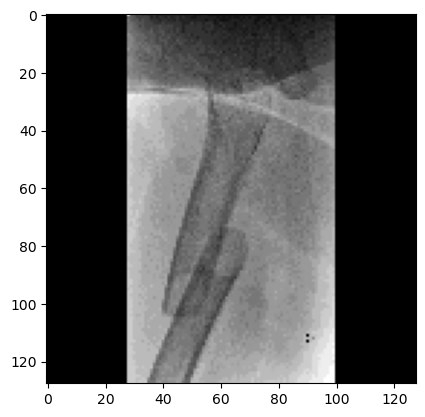

In [14]:
plot_img(f"{path}raw_gray_128/train_AFF/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_5.png")

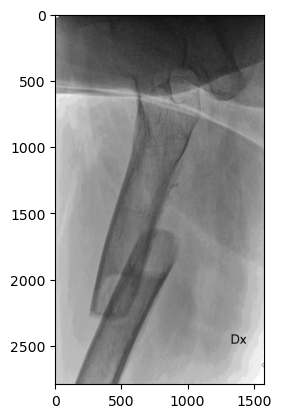

In [16]:
plot_img(f"{path}raw_gray/train_AFF/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_5.png")

In [17]:
img = cv2.imread(f"{path}raw_gray/train_AFF/patient_9_AFF_class_1_modality_CR_scanoccasion_0_imagenumber_5.png", cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.astype(np.float32)

normalized = (img - global_mean) / global_std + 128

In [20]:
img

array([[[102., 102., 102.],
        [ 85.,  85.,  85.],
        [ 85.,  85.,  85.],
        ...,
        [ 34.,  34.,  34.],
        [ 34.,  34.,  34.],
        [ 34.,  34.,  34.]],

       [[102., 102., 102.],
        [ 85.,  85.,  85.],
        [ 85.,  85.,  85.],
        ...,
        [ 17.,  17.,  17.],
        [ 34.,  34.,  34.],
        [ 34.,  34.,  34.]],

       [[102., 102., 102.],
        [102., 102., 102.],
        [ 85.,  85.,  85.],
        ...,
        [ 17.,  17.,  17.],
        [ 34.,  34.,  34.],
        [ 17.,  17.,  17.]],

       ...,

       [[  0.,   0.,   0.],
        [255., 255., 255.],
        [221., 221., 221.],
        ...,
        [255., 255., 255.],
        [255., 255., 255.],
        [255., 255., 255.]],

       [[  0.,   0.,   0.],
        [255., 255., 255.],
        [221., 221., 221.],
        ...,
        [255., 255., 255.],
        [255., 255., 255.],
        [255., 255., 255.]],

       [[  0.,   0.,   0.],
        [255., 255., 255.],
        [221., 2

In [19]:
global_mean

array([71.68476105, 71.68476105, 71.68476105])

In [18]:
normalized

array([[[128.37561202, 128.37561202, 128.37561202],
        [128.16497854, 128.16497854, 128.16497854],
        [128.16497854, 128.16497854, 128.16497854],
        ...,
        [127.53307809, 127.53307809, 127.53307809],
        [127.53307809, 127.53307809, 127.53307809],
        [127.53307809, 127.53307809, 127.53307809]],

       [[128.37561202, 128.37561202, 128.37561202],
        [128.16497854, 128.16497854, 128.16497854],
        [128.16497854, 128.16497854, 128.16497854],
        ...,
        [127.32244461, 127.32244461, 127.32244461],
        [127.53307809, 127.53307809, 127.53307809],
        [127.53307809, 127.53307809, 127.53307809]],

       [[128.37561202, 128.37561202, 128.37561202],
        [128.37561202, 128.37561202, 128.37561202],
        [128.16497854, 128.16497854, 128.16497854],
        ...,
        [127.32244461, 127.32244461, 127.32244461],
        [127.53307809, 127.53307809, 127.53307809],
        [127.32244461, 127.32244461, 127.32244461]],

       ...,

      

In [21]:
np.std(normalized)

np.float64(0.584960090164364)

In [22]:
np.mean(normalized)

np.float64(128.7168685257392)